In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from pyprojroot import here
import torch
from torch import nn
import torch.optim
from torchinfo import summary


from collections import defaultdict

import sys
sys.path.append(str(here("Scripts")))
from model_utils import train_test_split, one_hot_encode, FPLDataPipe, Trainer


In [3]:
data_path = here("Data/FPL_data.parquet")

In [4]:
data = pd.read_parquet(data_path)
data.head()

,name,position,team,element,opponent_team,was_home,gw,season_id,match_date,opp,goals_scored_ema_4,assists_ema_4,bonus_ema_4,clean_sheets_ema_4,creativity_ema_4,goals_conceded_ema_4,ict_index_ema_4,influence_ema_4,own_goals_ema_4,penalties_missed_ema_4,penalties_saved_ema_4,red_cards_ema_4,threat_ema_4,yellow_cards_ema_4,expected_assists_ema_4,expected_goals_ema_4,expected_goals_conceded_ema_4,team_h_score_ema_4,team_a_score_ema_4,gf_ema_4,ga_ema_4,sh_ema_4,sht_ema_4,corners_ema_4,yc_ema_4,rc_ema_4,fouls_ema_4,goals_scored_lagged_1,assists_lagged_1,bonus_lagged_1,bps_lagged_1,clean_sheets_lagged_1,creativity_lagged_1,goals_conceded_lagged_1,ict_index_lagged_1,influence_lagged_1,own_goals_lagged_1,penalties_missed_lagged_1,penalties_saved_lagged_1,red_cards_lagged_1,saves_lagged_1,threat_lagged_1,yellow_cards_lagged_1,starts_lagged_1,expected_assists_lagged_1,expected_goal_involvements_lagged_1,expected_goals_lagged_1,expected_goals_conceded_lagged_1,team_h_score_lagged_1,team_a_score_lagged_1,gf_lagged_1,ga_lagged_1,sh_lagged_1,sht_lagged_1,corners_lagged_1,yc_lagged_1,rc_lagged_1,fouls_lagged_1,xp_lagged_1,selected_lagged_1,transfers_balance_lagged_1,transfers_in_lagged_1,transfers_out_lagged_1,value_lagged_1,prob_draw,prob_loss,prob_u25,prob_ah_line,prob_ah_opp,total_points
0,Aaron Anselmino,DEF,Chelsea,774,5,False,25,2024-25,2025-02-14,Brighton,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0.277778,0.37037,0.420168,0.0,0.578035,0
1,Aaron Anselmino,DEF,Chelsea,774,2,False,26,2024-25,2025-02-22,Aston Villa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000,0.000,0.000,3.000,8.000,0.000,9.000,2.000,0.0,15.000,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,3,0,0,3,8,0,9,2,0,15,1.8,0,0,0,0,40,0.294118,0.380228,0.420168,0.0,0.505051,0
2,Aaron Anselmino,DEF,Chelsea,774,17,True,27,2024-25,2025-02-25,Southampton,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.600,0.400,0.400,2.600,10.800,2.800,6.600,2.400,0.0,15.400,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,2,1,1,2,15,7,3,3,0,16,0.5,156,82,92,10,40,0.125,0.076923,0.266667,0.0,0.518135,0
3,Aaron Anselmino,DEF,Chelsea,774,11,True,28,2024-25,2025-03-09,Leicester,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.160,0.240,1.840,1.560,14.080,5.680,5.560,1.840,0.0,11.640,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,4,0,4,0,19,10,4,1,0,6,1.0,236,29,58,29,40,0.125,0.083333,0.3125,0.0,0.512821,0
4,Aaron Anselmino,DEF,Chelsea,774,1,False,29,2024-25,2025-03-16,Arsenal,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.296,0.144,1.504,0.936,16.448,6.208,8.136,1.504,0.0,11.784,0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1,0,1,0,20,7,12,1,0,12,0.5,325,21,52,31,40,0.277778,0.555556,0.520833,1.0,0.485437,0


In [5]:
ema_cols = [c for c in data.columns if "ema" in c]
lagged_cols = [c for c in data.columns if "lag" in c]
prob_cols = [c for c in data.columns if "prob" in c]
metadata_cols  = [c for c in data.columns if c not in ema_cols+lagged_cols+prob_cols]
len(ema_cols), len(lagged_cols), len(prob_cols), len(metadata_cols)

(27, 37, 5, 11)

In [6]:
len(ema_cols) + len(lagged_cols) + len(prob_cols) + len(metadata_cols)

80

In [7]:
X_train, y_train, X_valid, y_valid, X_test, y_test = train_test_split(data)
X_train.shape

(81677, 79)

In [8]:
[c for c in ema_cols+lagged_cols+prob_cols+metadata_cols if c not in X_train.columns]

['total_points']

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [10]:
BATCH_SIZE = 256
fpl_data_pipe = FPLDataPipe(num_cols=ema_cols+lagged_cols+prob_cols,
                            cat_cols = ["position", "was_home"],
                            batch_size=BATCH_SIZE)

In [11]:
fpl_data_pipe.prepare_data(X_train=X_train,
                           X_valid=X_valid,
                           X_test=X_test,
                           y_train=y_train,
                           y_valid=y_valid,
                           y_test=y_test)

In [12]:
train_dataloader, valid_dataloader, test_dataloader = fpl_data_pipe.get_dataloaders()

In [13]:
x, y = next(iter(train_dataloader))
x.shape, y.shape

(torch.Size([256, 75]), torch.Size([256, 1]))

In [14]:
class MLP(nn.Module):
    def __init__(self, input_size: int,
                 hidden_size1: int,
                 hidden_size2: int,
                 output_size: int):
        super(MLP, self).__init__()

        block1 = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size1),
            nn.Dropout(0.3)
        )
        block2 = nn.Sequential(
            nn.Linear(hidden_size1, hidden_size2),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size2),
            nn.Dropout(0.2)
        )
        block3 = nn.Sequential(
            nn.Linear(hidden_size2, output_size)
        )

        self.block_stack = nn.Sequential(
            block1,
            block2,
            block3
        )

    def forward(self, x):
        return self.block_stack(x)

In [15]:
mlp = MLP(
    input_size=x.shape[1],
    hidden_size1=128,
    hidden_size2=64,
    output_size=1
).to(device)

In [16]:
summary(
    model=mlp,
    input_size=(64, 75),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18

)

Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Trainable
MLP                                      [64, 75]           [64, 1]            --                 True
├─Sequential: 1-1                        [64, 75]           [64, 1]            --                 True
│    └─Sequential: 2-1                   [64, 75]           [64, 128]          --                 True
│    │    └─Linear: 3-1                  [64, 75]           [64, 128]          9,728              True
│    │    └─LeakyReLU: 3-2               [64, 128]          [64, 128]          --                 --
│    │    └─BatchNorm1d: 3-3             [64, 128]          [64, 128]          256                True
│    │    └─Dropout: 3-4                 [64, 128]          [64, 128]          --                 --
│    └─Sequential: 2-2                   [64, 128]          [64, 64]           --                 True
│    │    └─Linear: 3-5                  [64, 128]          [64, 64]    

In [17]:
learning_rate = 0.0005
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(lr=learning_rate,
                            params=mlp.parameters(),
                            weight_decay=.001)


In [18]:
trainer = Trainer(device=device,
                  random_state=77)

In [19]:
results = trainer.model_eval(train_dataloader=train_dataloader,
                             test_dataloader=valid_dataloader,
                             model=mlp,
                             optimizer=optimizer,
                             loss_fn=loss_fn,
                             tolerance=0.001,
                             patience=10)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 5.4246 | Test Loss: 4.8943
Train MSE: 5.4103 | Test MSE: 4.8997
Train MAE: 1.2832 | Test MAE : 1.1896
Train R2: 0.0327 | Test R2 : 0.1612
Epoch: 10 | Train Loss: 4.3108 | Test Loss: 4.4176
Train MSE: 4.3039 | Test MSE: 4.4227
Train MAE: 1.2269 | Test MAE : 1.0756
Train R2: 0.2305 | Test R2 : 0.2428
Epoch: 20 | Train Loss: 4.2354 | Test Loss: 4.4599
Train MSE: 4.2292 | Test MSE: 4.4650
Train MAE: 1.2219 | Test MAE : 1.0842
Train R2: 0.2439 | Test R2 : 0.2356
Early stopping | No improvement since 10 epochs


In [20]:
results_frame = pd.DataFrame(results)
results_frame.tail()

,train_loss,test_loss,train_mse,test_mse,train_mae,test_mae,train_r2,test_r2
16,4.257188,4.455378,4.250655,4.460459,1.223725,1.099008,0.240051,0.236368
17,4.257051,4.454870,4.252635,4.459916,1.222928,1.096969,0.239697,0.236461
18,4.246870,4.448633,4.241952,4.453734,1.222638,1.080267,0.241607,0.237519
19,4.238020,4.466430,4.233665,4.471555,1.220112,1.085797,0.243088,0.234468
20,4.235385,4.459858,4.229212,4.464971,1.221884,1.084200,0.243885,0.235595


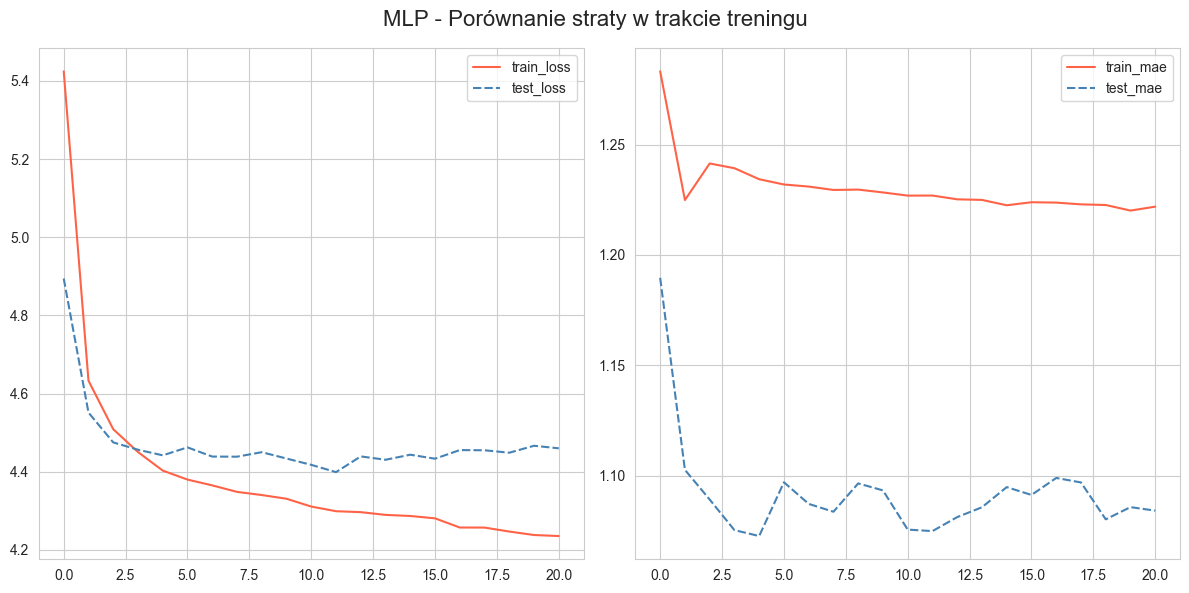

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.lineplot(results_frame[["train_loss", "test_loss"]],
             palette=["tomato", "steelblue"],
             ax=ax[0])
sns.lineplot(results_frame[["train_mae", "test_mae"]],
             palette=["tomato", "steelblue"],
             ax=ax[1])
fig.suptitle("MLP - Porównanie straty w trakcie treningu", fontsize=16);
plt.tight_layout()


In [22]:
test_results = defaultdict(list)

test_results["test_loss"].append(trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[0])
test_results["test_mse"].append(trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[1])
test_results["test_mae"].append(trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[2])
test_results["test_r2"].append(trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[3])

y_pred = trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[4]

In [23]:
y_pred.shape, y_test.shape

(torch.Size([18183, 1]), (18183,))

In [24]:
preds = pd.DataFrame({
    "name" : data.loc[data.season_id == "2025-26", "name"],
    "y_true": y_test,
    "y_pred": y_pred.numpy().flatten()
})

In [25]:
preds.y_pred.max(), preds.y_true.max()

(np.float32(7.413211), np.int64(24))

In [39]:
players = data.loc[data.season_id == "2025-26", "name"].sample(4, random_state=7)
players

25524     Dango Ouattara
85843        Matthew Cox
71309    Kristoffer Ajer
87619      Michael Keane
Name: name, dtype: string

<Figure size 1200x600 with 0 Axes>

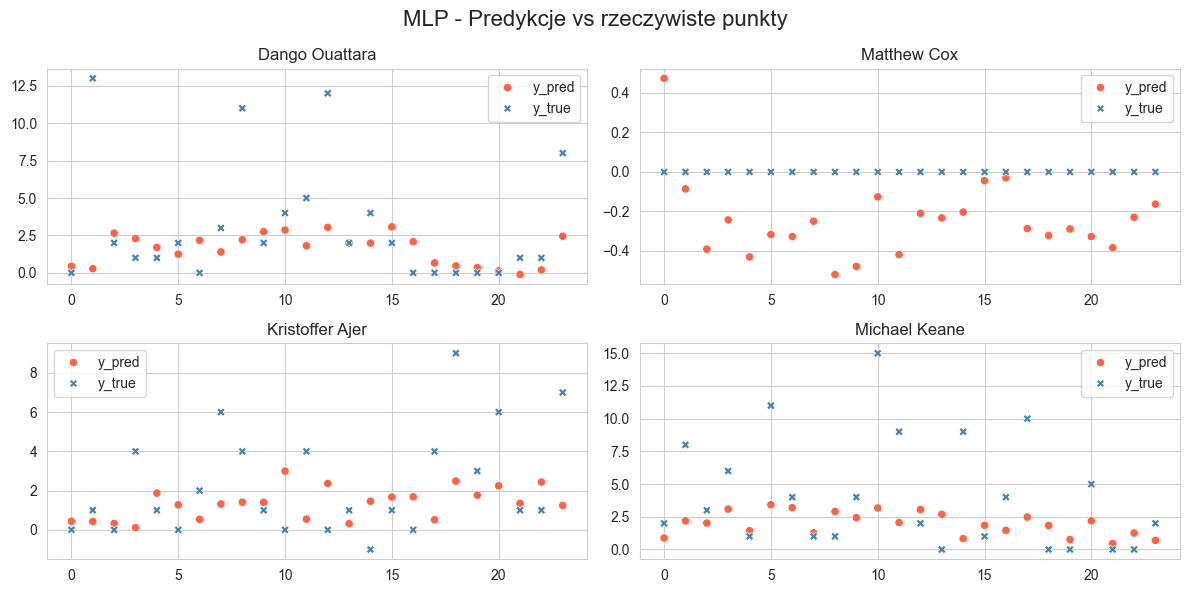

In [42]:
plt.figure(figsize=(12, 6))
fig, ax = plt.subplots(nrows=2, ncols=len(players) // 2, figsize=(12, 6))
for i, player in enumerate(players):
    sns.scatterplot(data=preds.loc[preds.name==player, ["y_pred", "y_true"]].reset_index(drop=True),
                    palette=["tomato", "steelblue"], ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(player)
plt.suptitle("MLP - Predykcje vs rzeczywiste punkty", fontsize=16)
plt.tight_layout();
